# XGBoost Regression — Predicting `duration_minutes`
### Gradient Boosted Trees with Early Stopping & Feature Importance

**Goal:** Build an XGBoost regressor to predict GitHub Actions workflow `duration_minutes` using YAML-derived and codebase features.

| Step | Description |
|------|-------------|
| 1 | Load & preprocess (type-cast, derive features) |
| 2 | IQR outlier removal on target |
| 3 | Encode categoricals (label encoding — XGBoost handles ordinals) |
| 4 | Train/validation/test split |
| 5 | Baseline XGBoost with early stopping |
| 6 | RandomizedSearchCV for hyperparameter optimisation |
| 7 | Feature importance (gain, weight, cover, SHAP-style) |
| 8 | Learning curves |
| 9 | Evaluation: R², Adjusted R², MAE, RMSE, MAPE |
| 10 | Residual diagnostics |
| 11 | Hyperparameter tuning tips |

**Note:** XGBoost handles multicollinearity gracefully — all relevant features are retained.

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, RandomizedSearchCV)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import xgboost as xgb
from xgboost import XGBRegressor

RANDOM_STATE = 42
TARGET = 'duration_minutes'
print(f'XGBoost version: {xgb.__version__}')
print('Imports complete ✓')

XGBoost version: 3.2.0
Imports complete ✓


---
## 1 · Load & Preprocess

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv('/content/drive/MyDrive/dataset/comprehensive_features.csv')
print(f'Raw shape: {df_raw.shape}')
df_raw.head()

Mounted at /content/drive
Raw shape: (9011, 26)


,total_cost_usd,duration_minutes,repo_name,head_sha,workflow_name,yaml_line_count,yaml_depth,job_count,total_steps,avg_steps_per_job,...,timeout_minutes,unique_actions_used,is_using_setup_actions,is_using_docker_actions,is_using_cache,env_var_count,if_condition_count,needs_dependencies_count,code_complexity,primary_language
0,0.0,0.0,vuejs/vue,b54c58cda9d42a5575a84bda927b4499718bbb6a,ci,93,5,4,23,5.8,...,0,3,True,False,False,0,0,0,0.012782,typescript
1,0.0,0.0,vuejs/vue,260556b441caf7127eb1b39fc41a722c282d4453,ci,93,5,4,23,5.8,...,0,3,True,False,False,0,0,0,0.012782,typescript
2,0.0,0.0,vuejs/vue,88a4969840b62610bfeaee9717f8bbf8c96f0147,ci,93,5,4,23,5.8,...,0,3,True,False,False,0,0,0,0.012782,typescript
3,0.0,0.0,vuejs/vue,330e8c7ec8069750054096870bfb719f7add961e,ci,93,5,4,23,5.8,...,0,3,True,False,False,0,0,0,0.012782,typescript
4,0.0,0.0,vuejs/vue,3005148a575e3d0044877577c870e15503a2ec5d,ci,93,5,4,23,5.8,...,0,3,True,False,False,0,0,0,0.012782,typescript


In [ ]:
# ── Drop excluded columns ──────────────────────────────────────────────
drop_cols = ['total_cost_usd', 'workflow_name', 'repo_name', 'head_sha']
df = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns]).copy()
print(f'Shape after dropping identifiers/leaky cols: {df.shape}')

Shape after dropping identifiers/leaky cols: (9011, 22)


In [ ]:
# ── Type casting ──────────────────────────────────────────────────────
bool_cols = ['uses_matrix_strategy', 'is_using_setup_actions',
             'is_using_docker_actions', 'is_using_cache']
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].map({'True': 1, 'False': 0, True: 1, False: 0}).astype(int)

# fail_fast: coerce expression strings → True (default runtime value)
def parse_fail_fast(v):
    if v == 'True':  return 1
    if v == 'False': return 0
    return 1

if 'fail_fast' in df.columns:
    df['fail_fast'] = df['fail_fast'].apply(parse_fail_fast)

# container_image → binary flag
if 'container_image' in df.columns:
    df['has_container'] = (df['container_image'] != 'False').astype(int)
    df.drop(columns=['container_image'], inplace=True)

# yaml_depth to numeric
if 'yaml_depth' in df.columns:
    df['yaml_depth'] = pd.to_numeric(df['yaml_depth'], errors='coerce')

print('Type casting complete ✓')
df.dtypes

Type casting complete ✓


,0
duration_minutes,float64
yaml_line_count,int64
yaml_depth,int64
job_count,int64
total_steps,int64
avg_steps_per_job,float64
uses_matrix_strategy,int64
matrix_dimensions,int64
matrix_permutations,int64
fail_fast,int64


---
## 2 · IQR Outlier Removal on Target

In [ ]:
Q1, Q3 = df[TARGET].quantile([0.25, 0.75])
IQR = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

n_before = len(df)
df = df[df[TARGET].between(lo, hi)].copy().reset_index(drop=True)
n_after = len(df)

print(f'Rows before: {n_before}')
print(f'Outliers removed: {n_before - n_after} (duration > {hi:.3f} min)')
print(f'Rows after: {n_after}')
print(f'Target range: {df[TARGET].min():.4f} – {df[TARGET].max():.4f} min')

Rows before: 9011
Outliers removed: 1149 (duration > 12.908 min)
Rows after: 7862
Target range: 0.0000 – 12.9000 min


---
## 3 · Encode Categoricals (Label Encoding)

XGBoost works well with label-encoded categoricals. This avoids dimensionality explosion from one-hot encoding.

In [ ]:
cat_cols = ['os_label', 'primary_language']
label_encoders = {}

for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nShape after encoding: {df.shape}')

os_label: {'macos': np.int64(0), 'self-hosted': np.int64(1), 'ubuntu': np.int64(2), 'windows': np.int64(3)}
primary_language: {'blade': np.int64(0), 'c': np.int64(1), 'c#': np.int64(2), 'c++': np.int64(3), 'dockerfile': np.int64(4), 'go': np.int64(5), 'groovy': np.int64(6), 'haskell': np.int64(7), 'html': np.int64(8), 'java': np.int64(9), 'javascript': np.int64(10), 'jupyter notebook': np.int64(11), 'kotlin': np.int64(12), 'llvm': np.int64(13), 'php': np.int64(14), 'python': np.int64(15), 'ruby': np.int64(16), 'rust': np.int64(17), 'shell': np.int64(18), 'typescript': np.int64(19), 'zig': np.int64(20)}

Shape after encoding: (7862, 22)


In [ ]:
# Handle any remaining NaN values
print(f'NaN counts before fill:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
df = df.fillna(0)
print(f'\nFinal shape: {df.shape}')

NaN counts before fill:
Series([], dtype: int64)

Final shape: (7862, 22)


---
## 4 · Train / Validation / Test Split

In [ ]:
# Separate features and target
y = df[TARGET].values
X = df.drop(columns=[TARGET])

# Use log1p-transformed target to stabilise variance
y_log = np.log1p(y)

# 60% train, 20% validation (for early stopping), 20% test
X_train_full, X_test, y_train_full_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X_train_full, y_train_full_log, test_size=0.25, random_state=RANDOM_STATE
)  # 0.25 × 0.8 = 0.2 → 60/20/20 split

# Keep original y values for back-transformed metrics
y_test_original = np.expm1(y_test_log)
y_val_original = np.expm1(y_val_log)

print(f'Features: {list(X.columns)}')
print(f'Feature count: {X.shape[1]}')
print(f'Train set:      {X_train.shape[0]} samples (60%)')
print(f'Validation set: {X_val.shape[0]} samples (20%)')
print(f'Test set:       {X_test.shape[0]} samples (20%)')

Features: ['yaml_line_count', 'yaml_depth', 'job_count', 'total_steps', 'avg_steps_per_job', 'uses_matrix_strategy', 'matrix_dimensions', 'matrix_permutations', 'fail_fast', 'os_label', 'timeout_minutes', 'unique_actions_used', 'is_using_setup_actions', 'is_using_docker_actions', 'is_using_cache', 'env_var_count', 'if_condition_count', 'needs_dependencies_count', 'code_complexity', 'primary_language', 'has_container']
Feature count: 21
Train set:      4716 samples (60%)
Validation set: 1573 samples (20%)
Test set:       1573 samples (20%)


---
## 5 · Baseline XGBoost with Early Stopping

In [ ]:
def evaluate_model(model_name, y_true_log, y_pred_log, n_features):
    """Compute metrics in both log and original scale."""
    r2_log = r2_score(y_true_log, y_pred_log)
    n = len(y_true_log)
    adj_r2_log = 1 - (1 - r2_log) * (n - 1) / (n - n_features - 1)

    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    y_pred_orig = np.maximum(y_pred_orig, 0)

    r2_orig = r2_score(y_true_orig, y_pred_orig)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))

    mask = y_true_orig > 0.01
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true_orig[mask] - y_pred_orig[mask]) / y_true_orig[mask])) * 100
    else:
        mape = np.nan

    metrics = {
        'Model': model_name,
        'R² (log)': round(r2_log, 4),
        'Adj R² (log)': round(adj_r2_log, 4),
        'R² (original)': round(r2_orig, 4),
        'MAE (min)': round(mae, 4),
        'RMSE (min)': round(rmse, 4),
        'MAPE (%)': round(mape, 2),
    }
    return metrics

print('Evaluation function defined ✓')

Evaluation function defined ✓


In [ ]:
# ── Baseline XGBoost ─────────────────────────────────────────────────
xgb_baseline = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse',
)

print('Training baseline XGBoost with early stopping...')
xgb_baseline.fit(
    X_train, y_train_log,
    eval_set=[(X_train, y_train_log), (X_val, y_val_log)],
    verbose=50,
)

print(f'\nBest iteration: {xgb_baseline.best_iteration}')
print(f'Best validation RMSE: {xgb_baseline.best_score:.4f}')

Training baseline XGBoost with early stopping...
[0]	validation_0-rmse:0.73846	validation_1-rmse:0.73882
[50]	validation_0-rmse:0.46507	validation_1-rmse:0.52496
[100]	validation_0-rmse:0.40199	validation_1-rmse:0.48895
[150]	validation_0-rmse:0.36606	validation_1-rmse:0.46897
[200]	validation_0-rmse:0.34556	validation_1-rmse:0.45925
[250]	validation_0-rmse:0.33236	validation_1-rmse:0.45589
[300]	validation_0-rmse:0.32333	validation_1-rmse:0.45441
[332]	validation_0-rmse:0.31856	validation_1-rmse:0.45475

Best iteration: 282
Best validation RMSE: 0.4533


In [ ]:
# ── Evaluate baseline ────────────────────────────────────────────────
y_pred_baseline = xgb_baseline.predict(X_test)

metrics_baseline = evaluate_model('XGB Baseline', y_test_log, y_pred_baseline, X.shape[1])
print('Baseline XGBoost Results:')
for k, v in metrics_baseline.items():
    print(f'  {k}: {v}')

# Overfitting check
y_pred_train = xgb_baseline.predict(X_train)
r2_train = r2_score(y_train_log, y_pred_train)
print(f'\n  Train R² (log): {r2_train:.4f}')
print(f'  Test R² (log):  {metrics_baseline["R² (log)"]}')
print(f'  Gap:            {r2_train - metrics_baseline["R² (log)"]:.4f}')

Baseline XGBoost Results:
  Model: XGB Baseline
  R² (log): 0.6392
  Adj R² (log): 0.6344
  R² (original): 0.5331
  MAE (min): 1.0347
  RMSE (min): 2.0702
  MAPE (%): 206.38

  Train R² (log): 0.8175
  Test R² (log):  0.6392
  Gap:            0.1783


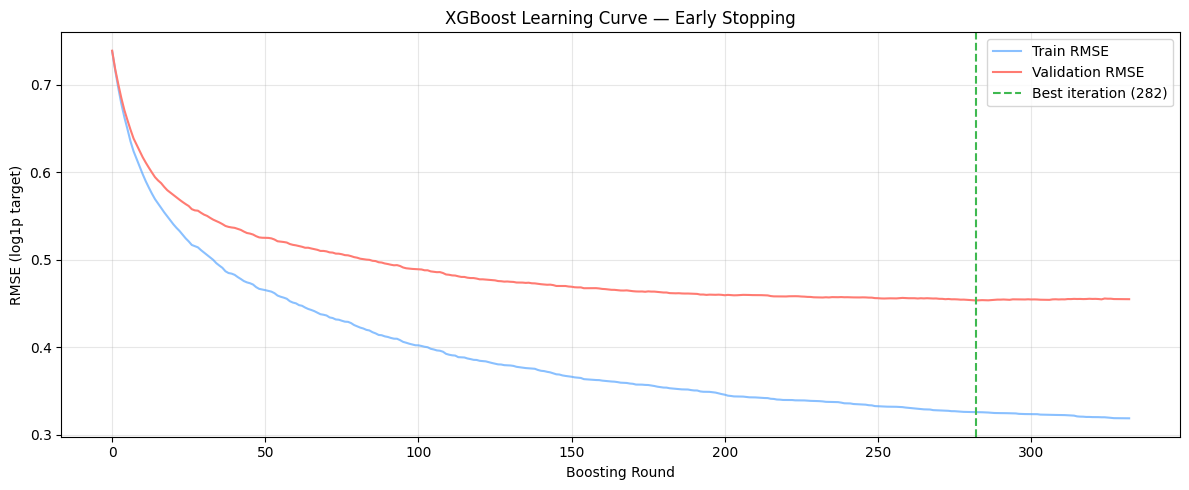

In [ ]:
# ── Learning curves (training vs validation loss) ────────────────────
results = xgb_baseline.evals_result()

fig, ax = plt.subplots(figsize=(12, 5))
epochs = range(len(results['validation_0']['rmse']))
ax.plot(epochs, results['validation_0']['rmse'], color='#58a6ff', lw=1.5,
        label='Train RMSE', alpha=0.7)
ax.plot(epochs, results['validation_1']['rmse'], color='#ff7b72', lw=1.5,
        label='Validation RMSE')
ax.axvline(xgb_baseline.best_iteration, color='#3fb950', lw=1.5, ls='--',
           label=f'Best iteration ({xgb_baseline.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (log1p target)')
ax.set_title('XGBoost Learning Curve — Early Stopping')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6 · RandomizedSearchCV — Hyperparameter Optimisation

In [ ]:
param_distributions = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0, 10.0],
    'reg_lambda': [0.1, 0.5, 1.0, 5.0, 10.0],
    'gamma': [0, 0.1, 0.5, 1.0, 5.0],
}

n_iter = 80
print(f'RandomizedSearchCV: {n_iter} random combinations × 3 folds')
print('This may take several minutes...\n')

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='rmse'),
    param_distributions=param_distributions,
    n_iter=n_iter,
    cv=3,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)
random_search.fit(X_train_full, y_train_full_log)

print(f'\nBest parameters: {random_search.best_params_}')
print(f'Best CV R² (log): {random_search.best_score_:.4f}')

RandomizedSearchCV: 80 random combinations × 3 folds
This may take several minutes...

Fitting 3 folds for each of 80 candidates, totalling 240 fits

Best parameters: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.5}
Best CV R² (log): 0.6722


In [ ]:
# ── Retrain best model with early stopping ───────────────────────────
best_params = random_search.best_params_.copy()
best_params['early_stopping_rounds'] = 50
best_params['eval_metric'] = 'rmse'
# Ensure n_estimators is high enough for early stopping to find optimum
best_params['n_estimators'] = max(best_params.get('n_estimators', 500), 1000)

xgb_tuned = XGBRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print('Retraining best model with early stopping...')
xgb_tuned.fit(
    X_train, y_train_log,
    eval_set=[(X_train, y_train_log), (X_val, y_val_log)],
    verbose=50,
)

print(f'\nBest iteration: {xgb_tuned.best_iteration}')
y_pred_tuned = xgb_tuned.predict(X_test)

metrics_tuned = evaluate_model('XGB Tuned', y_test_log, y_pred_tuned, X.shape[1])
print('\nTuned XGBoost Results:')
for k, v in metrics_tuned.items():
    print(f'  {k}: {v}')

# Overfitting check
y_pred_train_t = xgb_tuned.predict(X_train)
r2_train_t = r2_score(y_train_log, y_pred_train_t)
print(f'\n  Train R² (log): {r2_train_t:.4f}')
print(f'  Test R² (log):  {metrics_tuned["R² (log)"]}')
print(f'  Gap:            {r2_train_t - metrics_tuned["R² (log)"]:.4f}')

Retraining best model with early stopping...
[0]	validation_0-rmse:0.73425	validation_1-rmse:0.73563
[50]	validation_0-rmse:0.38036	validation_1-rmse:0.47211
[100]	validation_0-rmse:0.33452	validation_1-rmse:0.44724
[150]	validation_0-rmse:0.30992	validation_1-rmse:0.43703
[200]	validation_0-rmse:0.29251	validation_1-rmse:0.42902
[250]	validation_0-rmse:0.28309	validation_1-rmse:0.42772
[300]	validation_0-rmse:0.27607	validation_1-rmse:0.42696
[350]	validation_0-rmse:0.26961	validation_1-rmse:0.42610
[373]	validation_0-rmse:0.26793	validation_1-rmse:0.42616

Best iteration: 323

Tuned XGBoost Results:
  Model: XGB Tuned
  R² (log): 0.6906
  Adj R² (log): 0.6864
  R² (original): 0.6075
  MAE (min): 0.8606
  RMSE (min): 1.898
  MAPE (%): 143.24

  Train R² (log): 0.8721
  Test R² (log):  0.6906
  Gap:            0.1815


In [ ]:
# ── Top 10 hyperparameter combinations ───────────────────────────────
cv_df = pd.DataFrame(random_search.cv_results_)
cv_df = cv_df.sort_values('rank_test_score')
top_cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
            'mean_train_score', 'params']
print('=== Top 10 Hyperparameter Combinations ===')
display(cv_df[top_cols].head(10))

=== Top 10 Hyperparameter Combinations ===


,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
46,1,0.672235,0.024013,0.889846,"{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alp..."
5,2,0.664508,0.016165,0.868366,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alp..."
53,3,0.661546,0.020986,0.856028,"{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alp..."
77,4,0.655734,0.022790,0.864376,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp..."
3,5,0.653014,0.029314,0.884099,"{'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alp..."
22,6,0.647864,0.025595,0.865157,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alp..."
13,7,0.643430,0.026286,0.834919,"{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp..."
20,8,0.641396,0.026406,0.853211,"{'subsample': 0.7, 'reg_lambda': 0.1, 'reg_alp..."
42,9,0.640304,0.023209,0.829832,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alp..."
50,10,0.601427,0.023931,0.772664,"{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alp..."


---
## 7 · Feature Importance — Multiple Metrics

In [ ]:
# ── XGBoost built-in importance types ────────────────────────────────
importance_types = ['weight', 'gain', 'cover']
imp_dfs = {}

for imp_type in importance_types:
    scores = xgb_tuned.get_booster().get_score(importance_type=imp_type)
    # Map feature indices back to names
    imp_series = pd.Series(scores)
    # XGBoost may use f0, f1, etc. Map to actual feature names
    feature_map = {f'f{i}': col for i, col in enumerate(X.columns)}
    imp_series.index = [feature_map.get(idx, idx) for idx in imp_series.index]
    imp_series = imp_series.sort_values(ascending=False)
    imp_dfs[imp_type] = imp_series

print('=== Feature Importance (Gain — most reliable) ===')
for feat, val in imp_dfs['gain'].items():
    print(f'  {feat:<35} {val:.4f}')

=== Feature Importance (Gain — most reliable) ===
  os_label                            1.4975
  uses_matrix_strategy                1.2088
  is_using_setup_actions              0.9677
  unique_actions_used                 0.6269
  needs_dependencies_count            0.5111
  avg_steps_per_job                   0.4878
  total_steps                         0.4810
  timeout_minutes                     0.4685
  if_condition_count                  0.4592
  fail_fast                           0.4565
  code_complexity                     0.4424
  matrix_dimensions                   0.4356
  is_using_cache                      0.4156
  has_container                       0.4003
  env_var_count                       0.3631
  primary_language                    0.3533
  job_count                           0.3421
  yaml_line_count                     0.2989
  is_using_docker_actions             0.2666
  yaml_depth                          0.2569
  matrix_permutations                 0.2230


In [ ]:
# ── Permutation Importance ───────────────────────────────────────────
print('Computing permutation importance...')
perm_result = permutation_importance(
    xgb_tuned, X_test, y_test_log,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_imp = pd.DataFrame({
    'Feature': X.columns,
    'Mean': perm_result.importances_mean,
    'Std': perm_result.importances_std,
}).sort_values('Mean', ascending=False)

print('\n=== Permutation Importance (on test set) ===')
for _, row in perm_imp.iterrows():
    print(f'  {row["Feature"]:<35} {row["Mean"]:.4f} ± {row["Std"]:.4f}')

Computing permutation importance...

=== Permutation Importance (on test set) ===
  code_complexity                     0.1440 ± 0.0069
  unique_actions_used                 0.1202 ± 0.0052
  yaml_line_count                     0.0963 ± 0.0045
  total_steps                         0.0852 ± 0.0054
  primary_language                    0.0628 ± 0.0037
  avg_steps_per_job                   0.0541 ± 0.0061
  if_condition_count                  0.0537 ± 0.0048
  env_var_count                       0.0441 ± 0.0046
  uses_matrix_strategy                0.0379 ± 0.0034
  is_using_setup_actions              0.0333 ± 0.0032
  job_count                           0.0268 ± 0.0036
  timeout_minutes                     0.0235 ± 0.0035
  os_label                            0.0109 ± 0.0014
  yaml_depth                          0.0087 ± 0.0012
  needs_dependencies_count            0.0066 ± 0.0031
  fail_fast                           0.0042 ± 0.0021
  matrix_permutations                 0.0037 ± 0.0012


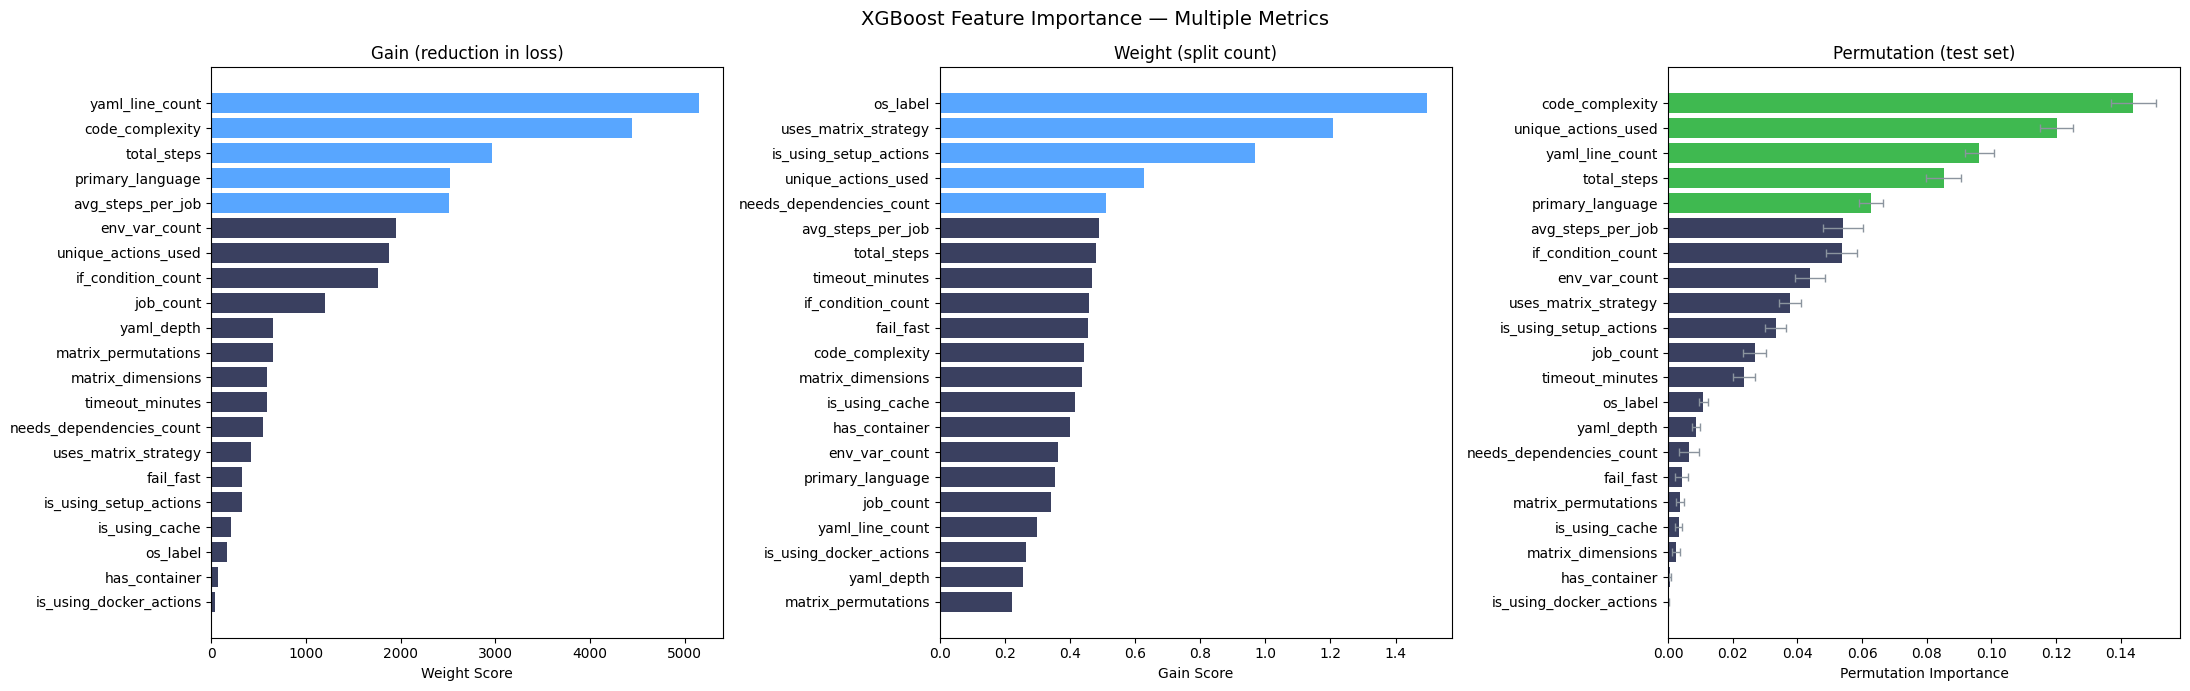

In [ ]:
# ── Visualise importance ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('XGBoost Feature Importance — Multiple Metrics', fontsize=14)

colors_list = ['#58a6ff', '#f0883e', '#3fb950']
titles = ['Gain (reduction in loss)', 'Weight (split count)', 'Permutation (test set)']

for idx, (title, color) in enumerate(zip(titles, colors_list)):
    ax = axes[idx]
    if idx < 2:
        imp_type = importance_types[idx]
        data = imp_dfs[imp_type].sort_values(ascending=True)
        highlight = ['#58a6ff' if i >= len(data) - 5 else '#3a4060'
                     for i in range(len(data))]
        ax.barh(data.index, data.values, color=highlight, edgecolor='none')
        ax.set_xlabel(f'{imp_type.capitalize()} Score')
    else:
        data = perm_imp.sort_values('Mean', ascending=True)
        highlight = ['#3fb950' if i >= len(data) - 5 else '#3a4060'
                     for i in range(len(data))]
        ax.barh(data['Feature'], data['Mean'],
                xerr=data['Std'], color=highlight, edgecolor='none',
                error_kw={'ecolor': '#8b949e', 'lw': 1, 'capsize': 3})
        ax.set_xlabel('Permutation Importance')
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## 8 · Model Comparison & Cross-Validation

In [ ]:
# ── Summary table ────────────────────────────────────────────────────
results_df = pd.DataFrame([metrics_baseline, metrics_tuned])
print('=== Model Comparison ===')
display(results_df)

=== Model Comparison ===


,Model,R² (log),Adj R² (log),R² (original),MAE (min),RMSE (min),MAPE (%)
0,XGB Baseline,0.6392,0.6344,0.5331,1.0347,2.0702,206.38
1,XGB Tuned,0.6906,0.6864,0.6075,0.8606,1.8980,143.24


In [ ]:
# ── Cross-validation on tuned model ──────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Use best params without early stopping for cross-val
cv_params = {k: v for k, v in random_search.best_params_.items()}

print('=== 5-Fold Cross-Validation R² (log1p target) ===')
xgb_models = {
    'XGB Baseline': XGBRegressor(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='rmse'),
    'XGB Tuned': XGBRegressor(
        **cv_params,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='rmse'),
}

cv_scores = {}
for name, model in xgb_models.items():
    scores = cross_val_score(model, X, y_log, cv=kf, scoring='r2')
    cv_scores[name] = scores
    print(f'  {name:15s}: mean R² = {scores.mean():.4f} ± {scores.std():.4f}  '
          f'[{scores.min():.4f}, {scores.max():.4f}]')

=== 5-Fold Cross-Validation R² (log1p target) ===
  XGB Baseline   : mean R² = 0.7111 ± 0.0138  [0.6841, 0.7227]
  XGB Tuned      : mean R² = 0.7249 ± 0.0166  [0.6948, 0.7441]


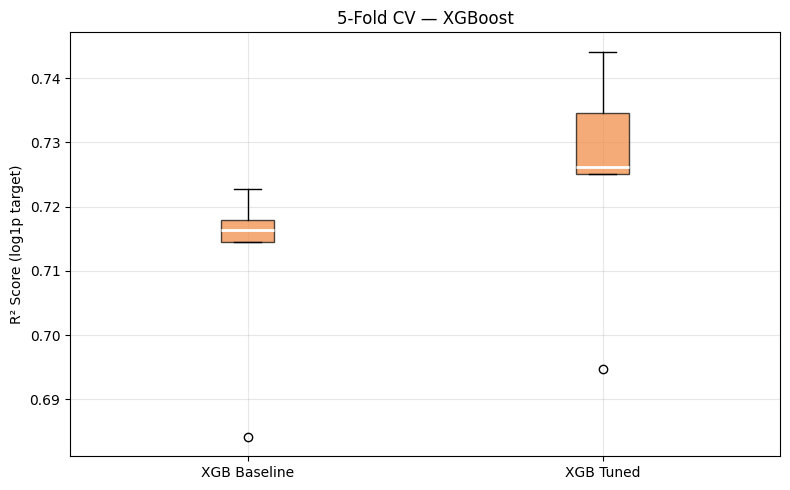

In [ ]:
# ── CV boxplot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([cv_scores[m] for m in xgb_models],
           labels=list(xgb_models.keys()), patch_artist=True,
           boxprops=dict(facecolor='#f0883e', alpha=0.7),
           medianprops=dict(color='white', lw=2))
ax.set_ylabel('R² Score (log1p target)')
ax.set_title('5-Fold CV — XGBoost')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9 · Residual Diagnostics

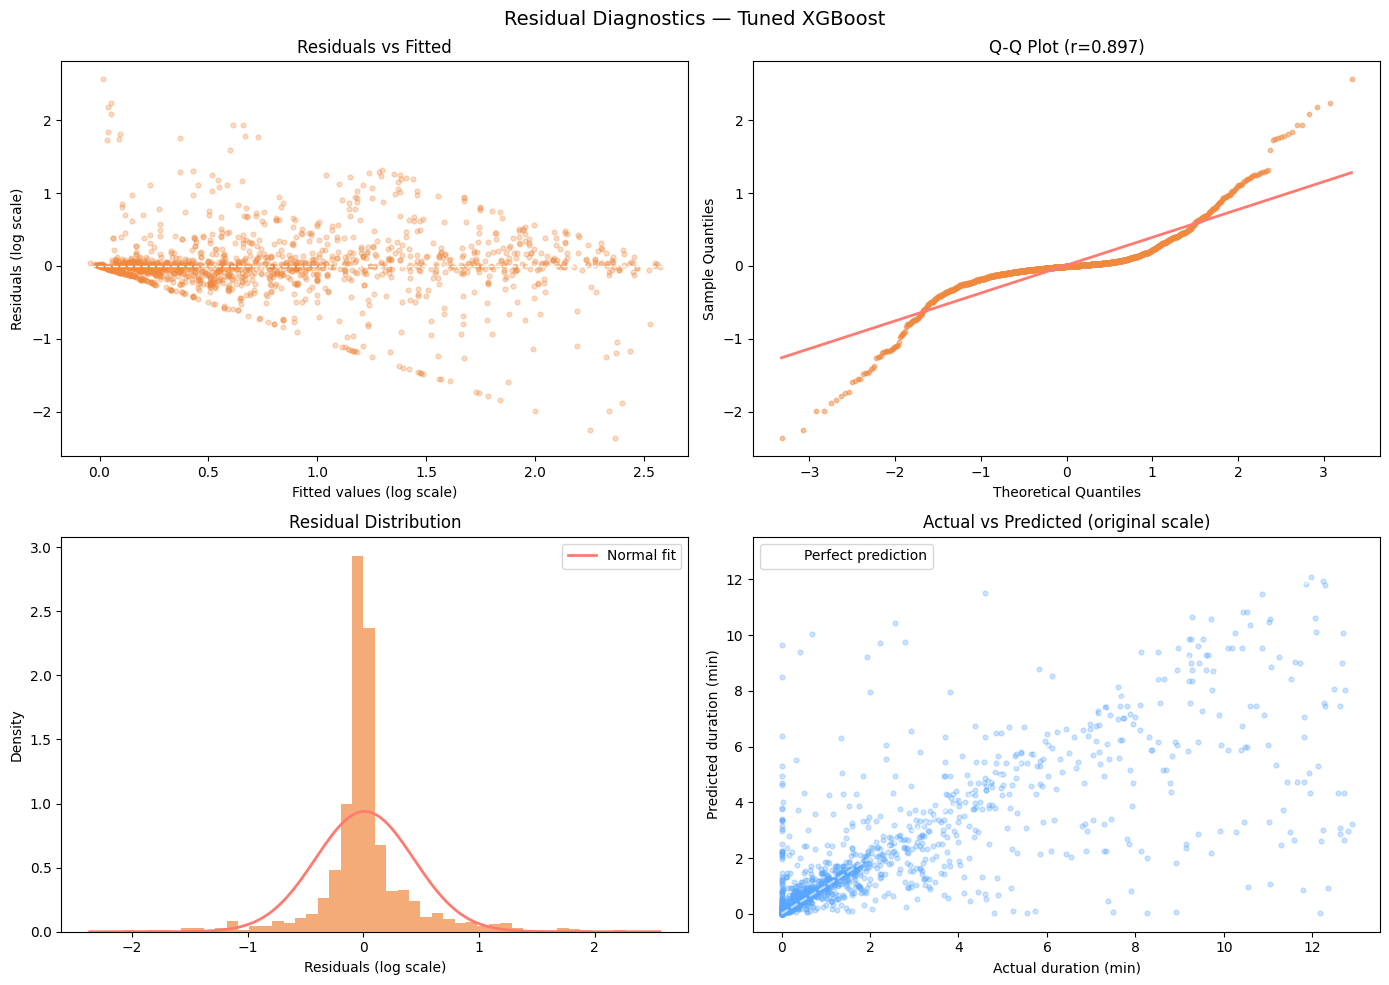

In [ ]:
residuals_log = y_test_log - y_pred_tuned
y_pred_orig = np.expm1(y_pred_tuned)
y_pred_orig = np.maximum(y_pred_orig, 0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Diagnostics — Tuned XGBoost', fontsize=14)

# 1. Residuals vs Fitted (log scale)
ax = axes[0, 0]
ax.scatter(y_pred_tuned, residuals_log, alpha=0.3, s=12, color='#f0883e')
ax.axhline(0, color='white', lw=1, ls='--')
ax.set_xlabel('Fitted values (log scale)')
ax.set_ylabel('Residuals (log scale)')
ax.set_title('Residuals vs Fitted')

# 2. Q-Q plot of residuals
ax = axes[0, 1]
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residuals_log, dist='norm')
ax.scatter(osm, osr, color='#f0883e', s=10, alpha=0.5)
xl = np.linspace(min(osm), max(osm), 100)
ax.plot(xl, slope * xl + intercept, color='#ff7b72', lw=2)
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title(f'Q-Q Plot (r={r_qq:.3f})')

# 3. Histogram of residuals
ax = axes[1, 0]
ax.hist(residuals_log, bins=50, color='#f0883e', alpha=0.7, edgecolor='none', density=True)
x_range = np.linspace(residuals_log.min(), residuals_log.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, residuals_log.mean(), residuals_log.std()),
        color='#ff7b72', lw=2, label='Normal fit')
ax.set_xlabel('Residuals (log scale)')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend()

# 4. Actual vs Predicted (original scale)
ax = axes[1, 1]
ax.scatter(y_test_original, y_pred_orig, alpha=0.3, s=12, color='#58a6ff')
lim = max(y_test_original.max(), y_pred_orig.max())
ax.plot([0, lim], [0, lim], 'w--', lw=1.5, alpha=0.6, label='Perfect prediction')
ax.set_xlabel('Actual duration (min)')
ax.set_ylabel('Predicted duration (min)')
ax.set_title('Actual vs Predicted (original scale)')
ax.legend()

plt.tight_layout()
plt.show()

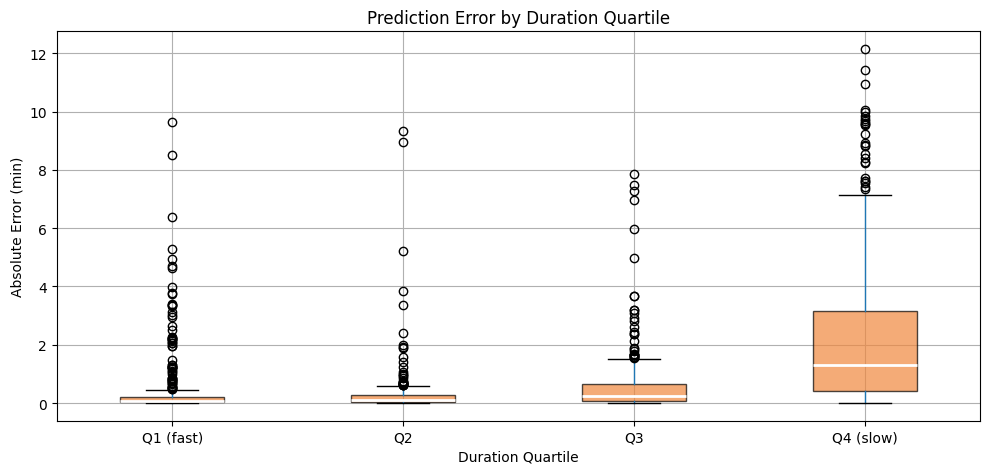

Error stats by quartile:
           count    mean     std     min     25%     50%     75%      max
dur_bin                                                                  
Q1 (fast)  404.0  0.3988  1.0567  0.0000  0.0182  0.0638  0.1956   9.6621
Q2         390.0  0.2686  0.7836  0.0002  0.0379  0.0879  0.2622   9.3421
Q3         386.0  0.5575  0.9904  0.0002  0.0857  0.2514  0.6542   7.8713
Q4 (slow)  393.0  2.2207  2.4998  0.0013  0.4279  1.2911  3.1528  12.1507


In [ ]:
# ── Error distribution by duration quantile ──────────────────────────
error_df = pd.DataFrame({
    'actual': y_test_original,
    'predicted': y_pred_orig,
    'abs_error': np.abs(y_test_original - y_pred_orig),
})
error_df['dur_bin'] = pd.qcut(error_df['actual'], q=4,
                               labels=['Q1 (fast)', 'Q2', 'Q3', 'Q4 (slow)'])

fig, ax = plt.subplots(figsize=(10, 5))
error_df.boxplot(column='abs_error', by='dur_bin', ax=ax,
                  patch_artist=True,
                  boxprops=dict(facecolor='#f0883e', alpha=0.7),
                  medianprops=dict(color='white', lw=2))
ax.set_xlabel('Duration Quartile')
ax.set_ylabel('Absolute Error (min)')
ax.set_title('Prediction Error by Duration Quartile')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Error stats by quartile:')
print(error_df.groupby('dur_bin')['abs_error'].describe().round(4))

---
## 10 · Tuned Model Learning Curve

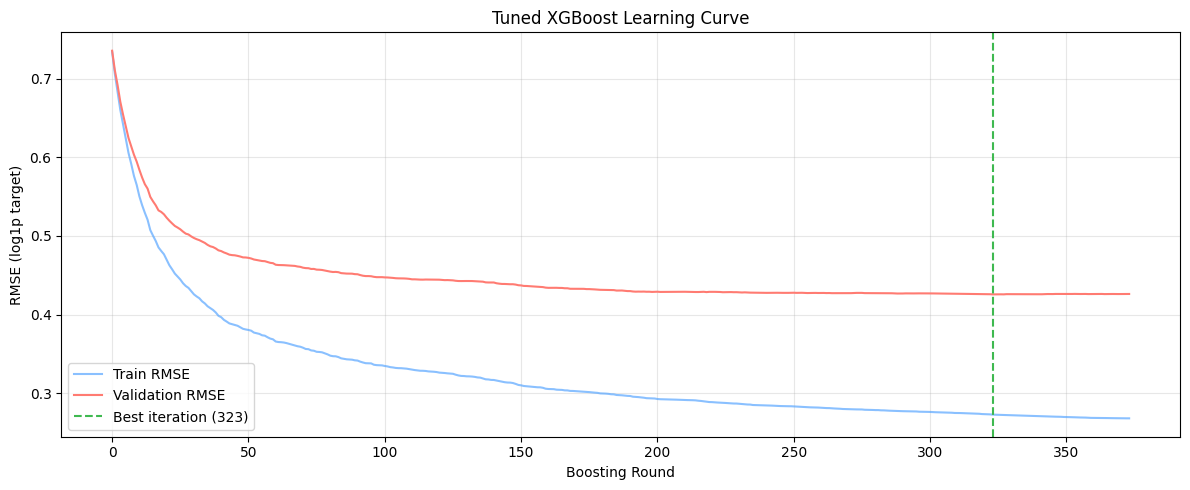

In [ ]:
# ── Learning curve of tuned model ────────────────────────────────────
results_tuned = xgb_tuned.evals_result()

fig, ax = plt.subplots(figsize=(12, 5))
epochs = range(len(results_tuned['validation_0']['rmse']))
ax.plot(epochs, results_tuned['validation_0']['rmse'], color='#58a6ff', lw=1.5,
        label='Train RMSE', alpha=0.7)
ax.plot(epochs, results_tuned['validation_1']['rmse'], color='#ff7b72', lw=1.5,
        label='Validation RMSE')
ax.axvline(xgb_tuned.best_iteration, color='#3fb950', lw=1.5, ls='--',
           label=f'Best iteration ({xgb_tuned.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (log1p target)')
ax.set_title('Tuned XGBoost Learning Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11 · Hyperparameter Tuning Tips for XGBoost

### Key Hyperparameters (ordered by typical impact)

#### `learning_rate` (eta)
- Step size shrinkage at each boosting round.
- **Lower rate** → needs more trees (`n_estimators`) but generalises better.
- Typical: `0.01–0.3`. Start with `0.1`, then try `0.01–0.05` with more trees.
- **Always pair with early stopping** to find optimal `n_estimators` automatically.

#### `max_depth` (Tree Depth)
- Controls complexity of each tree.
- **Deeper trees** → more complex patterns, higher overfitting risk.
- Typical: `3–10`. XGBoost default is 6.
- For tabular data with few features, `4–6` usually suffices.

#### `min_child_weight`
- Minimum sum of instance weights in a child node.
- **Higher values** → more conservative splits → regularisation.
- Typical: `1–10`. Increase if overfitting.

#### `subsample` (Row Sampling)
- Fraction of training data used per tree.
- Acts as **stochastic regularisation** (like dropout).
- Typical: `0.6–1.0`. Try `0.8` first.

#### `colsample_bytree` (Column Sampling)
- Fraction of features sampled per tree.
- Decorrelates trees, similar to Random Forest's `max_features`.
- Typical: `0.5–1.0`. Try `0.8` first.

#### `gamma` (Min Loss Reduction for Split)
- Minimum loss reduction required to make a split.
- `0` = no constraint. Higher values → fewer splits → more conservative.
- Typical: `0–5`. Start with `0`, increase if overfitting.

#### `reg_alpha` (L1 Regularisation) & `reg_lambda` (L2 Regularisation)
- `reg_alpha` → sparse weights (feature selection via L1).
- `reg_lambda` → smoother weights (default=1, good baseline).
- Try `[0, 0.01, 0.1, 1, 10]` for both.

### Tuning Strategy (Recommended Order)
1. Fix `learning_rate=0.1`, use **early stopping** to find `n_estimators`.
2. Tune `max_depth` and `min_child_weight` together.
3. Tune `subsample` and `colsample_bytree` together.
4. Tune `gamma`, `reg_alpha`, `reg_lambda`.
5. **Lower `learning_rate`** to `0.01–0.05` and re-run early stopping for final model.

### General Tips
- **No feature scaling needed** — tree-based model.
- **Label encoding** suffices for categoricals.
- **Always use early stopping** to prevent overfitting and automatically determine `n_estimators`.
- Monitor **train-test gap** — XGBoost can easily overfit without regularisation.
- **Gain importance** is the most reliable built-in importance metric.
- For **production**, serialise with `model.save_model('model.json')` (includes feature names).
- Consider **SHAP** values for interpretable feature importance (`shap.TreeExplainer`).

In [ ]:
print('═══ XGBOOST REGRESSION SUMMARY ═════════════════════════════════════════')
print()
print(f'Best model: XGB Tuned')
print(f'  R² (log scale):      {metrics_tuned["R² (log)"]}')
print(f'  Adj R² (log scale):  {metrics_tuned["Adj R² (log)"]}')
print(f'  R² (original scale): {metrics_tuned["R² (original)"]}')
print(f'  MAE:                 {metrics_tuned["MAE (min)"]} min')
print(f'  RMSE:                {metrics_tuned["RMSE (min)"]} min')
print(f'  MAPE:                {metrics_tuned["MAPE (%)"]}%')
print()
print(f'Best hyperparameters:')
for k, v in random_search.best_params_.items():
    print(f'  {k:<25} {v}')
print(f'  early_stopping_rounds  50')
print(f'  best_iteration         {xgb_tuned.best_iteration}')
print()
print(f'Features used: {X.shape[1]}')
print()
print('Top 5 features (Gain):')
for feat, val in list(imp_dfs['gain'].items())[:5]:
    print(f'  {feat:<35} {val:.4f}')
print('\n✓ XGBoost Regression notebook complete.')

═══ XGBOOST REGRESSION SUMMARY ═════════════════════════════════════════

Best model: XGB Tuned
  R² (log scale):      0.6906
  Adj R² (log scale):  0.6864
  R² (original scale): 0.6075
  MAE:                 0.8606 min
  RMSE:                1.898 min
  MAPE:                143.24%

Best hyperparameters:
  subsample                 1.0
  reg_lambda                0.1
  reg_alpha                 0.01
  n_estimators              1000
  min_child_weight          5
  max_depth                 8
  learning_rate             0.1
  gamma                     0
  colsample_bytree          0.5
  early_stopping_rounds  50
  best_iteration         323

Features used: 21

Top 5 features (Gain):
  os_label                            1.4975
  uses_matrix_strategy                1.2088
  is_using_setup_actions              0.9677
  unique_actions_used                 0.6269
  needs_dependencies_count            0.5111

✓ XGBoost Regression notebook complete.
